## 0. Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import sklearn
from sklearn.preprocessing import FunctionTransformer, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

In [2]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sklearn.set_config(transform_output="pandas")

## 1. Data Loading

In [3]:
df = pd.read_csv("cinemas.csv", index_col=0)
df.head(10)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
0,Color,James Cameron,723.0000,178.0000,0.0000,855.0000,Joel David Moore,1000.0000,760505847.0000,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054,English,USA,PG-13,237000000.0000,2009.0000,936.0000,7.9000,1.7800,33000,NaN,4,0
1,Color,Gore Verbinski,302.0000,169.0000,563.0000,1000.0000,Orlando Bloom,40000.0000,309404152.0000,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238,English,USA,PG-13,300000000.0000,2007.0000,5000.0000,7.1000,2.3500,0,NaN,8,0
2,Color,Sam Mendes,602.0000,148.0000,0.0000,161.0000,Rory Kinnear,11000.0000,200074175.0000,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994,English,UK,PG-13,245000000.0000,2015.0000,393.0000,6.8000,2.3500,85000,NaN,1,0
3,Color,Christopher Nolan,813.0000,164.0000,22000.0000,23000.0000,Christian Bale,27000.0000,448130642.0000,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701,English,USA,PG-13,250000000.0000,2012.0000,23000.0000,8.5000,2.3500,164000,NaN,3,0
4,NaN,Doug Walker,NaN,NaN,131.0000,NaN,Rob Walker,131.0000,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens,8,143,NaN,0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0000,7.1000,NaN,0,NaN,9,0
5,Color,Andrew Stanton,462.0000,132.0000,475.0000,530.0000,Samantha Morton,640.0000,73058679.0000,Action|Adventure|Sci-Fi,Daryl Sabara,John Carter,212204,1873,Polly Walker,1,alien|american civil war|male nipple|mars|prin...,http://www.imdb.com/title/tt0401729/?ref_=fn_t...,738,English,USA,PG-13,263700000.0000,2012.0000,632.0000,6.6000,2.3500,24000,NaN,3,0
6,Color,Sam Raimi,392.0000,156.0000,0.0000,4000.0000,James Franco,24000.0000,336530303.0000,Action|Adventure|Romance,J.K. Simmons,Spider-Man 3,383056,46055,Kirsten Dunst,0,sandman|spider man|symbiote|venom|villain,http://www.imdb.com/title/tt0413300/?ref_=fn_t...,1902,English,USA,PG-13,258000000.0000,2007.0000,11000.0000,6.2000,2.3500,0,NaN,2,0
7,Color,Nathan Greno,324.0000,100.0000,15.0000,284.0000,Donna Murphy,799.0000,200807262.0000,Adventure|Animation|Comedy|Family|Fantasy|Musi...,Brad Garrett,Tangled,294810,2036,M.C. Gainey,1,17th century|based on fairy tale|disney|flower...,http://www.imdb.com/title/tt0398286/?ref_=fn_t...,387,English,USA,PG,260000000.0000,2010.0000,553.0000,7.8000,1.8500,29000,NaN,1,0
8,Color,Joss Whedon,635.0000,141.0000,0.0000,19000.0000,Robert Downey Jr.,26000.0000,458991599.0000,Action|Adventure|Sci-Fi,Chris Hemsworth,Avengers: Age of Ultron,462669,92000,Scarlett Johansson,4,artificial intelligence|based on comic book|ca...,http://www.imdb.com/title/tt2395427/?ref_=fn_t...,1117,English,USA,PG-13,250000000.0000,2015.0000,21000.0000,7.5000,2.3500,118000,NaN,4,0
9,Color,David Yates,375.0000,153.0000,282.0000,10000.0000,Daniel Radcliffe,25000.0000,301956980.0000,Adventure|Family|Fantasy|Mystery,Alan Rickman,Harry Potter and the Half-Blood Prince,321795,58753,Rupert Grint,3,blood|book|love|potion|professor,http://www.imdb.com/title/tt0417741/?ref_=fn_t...,973,English,UK,PG,250000000.0000,2009.0000,11000.0000,7.5000,2.3500,

## 2. EDA

### 2.0 Data overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5031 non-null   str    
 1   director_name              4946 non-null   str    
 2   num_critic_for_reviews     5000 non-null   float64
 3   duration                   5035 non-null   float64
 4   director_facebook_likes    4946 non-null   float64
 5   actor_3_facebook_likes     5027 non-null   float64
 6   actor_2_name               5037 non-null   str    
 7   actor_1_facebook_likes     5043 non-null   float64
 8   gross                      4161 non-null   float64
 9   genres                     5050 non-null   str    
 10  actor_1_name               5043 non-null   str    
 11  movie_title                5050 non-null   str    
 12  num_voted_users            5050 non-null   str    
 13  cast_total_facebook_likes  5050 non-null   int64  
 14  act

In [5]:
df[~df["Unnamed: 28"].isna()]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
1761,Color,IC Wiener,666.0000,69.0000,17.0000,100500.0000,Nibbler,-32.0000,1111111.0000,Fantasy|Comedy|Sci-Fi,Philip J. Fry,No name yet,41,404,Turangalila,7,future|mission|space|delivery|bite my shiny me...,http://www.imdb.com/title/tt0119210/?ref_=fn_t...,25,English,USA,R,37000001.0000,1999.0000,102.0000,6.9000,1.8500,123,0.0030,1,0
5038,Color,Thomas L. Phillips,13.0000,82.0000,120.0000,84.0000,Joe Coffey,785.0000,NaN,Comedy|Horror|Thriller,Julianna Pitt,Sanctuary,Quite a Conundrum,133,1111,John Lucas,NaN,nudity|party|pirate|swimsuit|three word title,http://www.imdb.com/title/tt2049518/?ref_=fn_t...,8,English,USA,NaN,200000.0000,2012.0000,98.0000,5.4000,16,424.0000,3,0


In [6]:
# there is shift in first row, so we fix it by hand
row_index = df[df.movie_title == "Sanctuary"].index
df.iloc[row_index, :]
df.iloc[row_index, 11] = df.iloc[row_index, 11] + " " + df.iloc[row_index, 12]
df.iloc[row_index, 12] = str(df.iloc[row_index, 13].values[0])
df.iloc[row_index, 13] = int(df.iloc[row_index, 14].values[0])
df.iloc[row_index, 14] = df.iloc[row_index, 15]
df.iloc[row_index, 15] = df.iloc[row_index, 16]
df.iloc[row_index, 16] = df.iloc[row_index, 17]
df.iloc[row_index, 17] = df.iloc[row_index, 18]
df.iloc[row_index, 18] = df.iloc[row_index, 19]
df.iloc[row_index, 19] = df.iloc[row_index, 20]
df.iloc[row_index, 20] = df.iloc[row_index, 21]
df.iloc[row_index, 21] = np.nan
df.iloc[row_index, 22] = df.iloc[row_index, 23]
df.iloc[row_index, 23] = df.iloc[row_index, 24]
df.iloc[row_index, 24] = df.iloc[row_index, 25]
df.iloc[row_index, 25] = df.iloc[row_index, 26]
df.iloc[row_index, 26] = df.iloc[row_index, 27]
df.iloc[row_index, 27] = df.iloc[row_index, 28]
df.iloc[row_index,:]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
5038,Color,Thomas L. Phillips,13.0000,82.0000,120.0000,84.0000,Joe Coffey,785.0000,NaN,Comedy|Horror|Thriller,Julianna Pitt,Sanctuary Quite a Conundrum,133,1111,John Lucas,NaN,nudity|party|pirate|swimsuit|three word title,http://www.imdb.com/title/tt2049518/?ref_=fn_t...,8,English,USA,NaN,200000.0000,2012.0000,98.0000,5.4000,16.0000,424,424.0000,3,0


In [7]:
# in second row there are some fake data, so we delete it. We also drop this uselles column
df = df[df.director_name!="IC Wiener"]
df.drop("Unnamed: 28", axis = 1, inplace=True)

In [8]:
df.iloc[:,15:].info()

<class 'pandas.DataFrame'>
Index: 5049 entries, 0 to 5049
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   facenumber_in_poster    5036 non-null   str    
 1   plot_keywords           4896 non-null   str    
 2   movie_imdb_link         5049 non-null   str    
 3   num_user_for_reviews    5028 non-null   str    
 4   language                5035 non-null   str    
 5   country                 5044 non-null   str    
 6   content_rating          4740 non-null   str    
 7   budget                  4557 non-null   float64
 8   title_year              4941 non-null   float64
 9   actor_2_facebook_likes  5036 non-null   float64
 10  imdb_score              5049 non-null   float64
 11  aspect_ratio            4720 non-null   float64
 12  movie_facebook_likes    5049 non-null   int64  
 13  war_symb_title          5049 non-null   int64  
 14  point_symb_title        5049 non-null   int64  
dtypes: 

In [9]:
# df[pd.to_numeric(df.num_user_for_reviews,errors="coerce").isna()] # check
# df[pd.to_numeric(df.num_critic_for_reviews,errors="coerce").isna()] # check 
# df[pd.to_numeric(df.num_voted_users, errors="coerce").isna()] # check 
# df[pd.to_numeric(df.facenumber_in_poster, errors="coerce").isna()] # check 
df["num_user_for_reviews"] = pd.to_numeric(df.num_user_for_reviews, errors="coerce")
df["num_critic_for_reviews"] = pd.to_numeric(df.num_critic_for_reviews, errors="coerce")
df["num_voted_users"] = pd.to_numeric(df.num_voted_users, errors="coerce")
df["facenumber_in_poster"] = pd.to_numeric(df.facenumber_in_poster, errors="coerce")

In [10]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
count,4999.0000,5034.0000,4945.0000,5026.0000,5042.0000,4160.0000,5049.0000,5049.0000,5036.0000,5028.0000,4557.0000,4941.0000,5036.0000,5049.0000,4720.0000,5049.0000,5049.0000,5049.0000
mean,140.0620,107.1822,686.5270,644.6626,6553.1400,49525132.5356,83579.0347,9690.1737,1.3721,272.4916,39705095.5905,2002.4784,1650.4682,6.4434,2.2197,7518.8831,2.2151,0.0073
std,121.6005,25.1897,2811.6213,1664.0823,15013.1528,96592044.4331,138427.6812,18154.8347,2.0126,377.8440,205983492.2309,12.4701,4040.2108,1.1256,1.3844,19310.2691,1.7156,0.1132
min,1.0000,7.0000,0.0000,0.0000,0.0000,162.0000,5.0000,0.0000,0.0000,1.0000,218.0000,1916.0000,0.0000,1.6000,1.0000,0.0000,0.0000,0.0000
25%,50.0000,93.0000,7.0000,133.0000,614.2500,5344652.2500,8546.0000,1412.0000,0.0000,64.0000,6000000.0000,1999.0000,281.0000,5.8000,1.8500,0.0000,1.0000,0.0000
50%,110.0000,103.0000,49.0000,372.0000,986.0000,25522997.5000,34338.0000,3086.0000,1.0000,156.0000,20000000.0000,2005.0000,595.0000,6.6000,2.3500,166.0000,2.0000,0.0000
75%,195.0000,118.0000,197.0000,636.0000,11000.0000,62319416.0000,96129.0000,13748.0000,2.0000,325.2500,44500000.0000,2011.0000,918.0000,7.2000,2.3500,3000.0000,3.0000,0.0000
max,813.0000,511.0000,23000.0000,23000.0000,640000.0000,4444444444.0000,1689764.0000,656730.0000,43.0000,5060.0000,12215500000.0000,2019.0000,137000.0000,9.9000,16.0000,349000.0000,16.0000,5.0000


In [11]:
numeric_feauteres = df.select_dtypes(include=[np.number]).columns.to_list()
non_numeric_feauteres = df.select_dtypes(include=['str']).columns.to_list()
print(f"numeric features({len(numeric_feauteres)}): {numeric_feauteres}\nnon-numeric features({len(non_numeric_feauteres)}): ", non_numeric_feauteres)

numeric features(18): ['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'war_symb_title', 'point_symb_title']
non-numeric features(12):  ['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'language', 'country', 'content_rating']


### 2.1 missing values, duplicates and useless columns

In [12]:
(df.notnull().sum() / len(df)).sort_values(ascending=True)

gross                       0.8239
budget                      0.9026
aspect_ratio                0.9348
content_rating              0.9388
plot_keywords               0.9697
title_year                  0.9786
director_name               0.9794
director_facebook_likes     0.9794
num_critic_for_reviews      0.9901
actor_3_name                0.9954
actor_3_facebook_likes      0.9954
num_user_for_reviews        0.9958
color                       0.9962
duration                    0.9970
language                    0.9972
facenumber_in_poster        0.9974
actor_2_facebook_likes      0.9974
actor_2_name                0.9974
actor_1_name                0.9986
actor_1_facebook_likes      0.9986
country                     0.9990
cast_total_facebook_likes   1.0000
movie_facebook_likes        1.0000
imdb_score                  1.0000
genres                      1.0000
movie_imdb_link             1.0000
movie_title                 1.0000
war_symb_title              1.0000
num_voted_users     

In [13]:
df[df.duplicated(keep="first")].sort_values(by="num_critic_for_reviews") # 50 rows
df = df.drop_duplicates()
len(df)

4999

In [14]:
df[df.duplicated(keep=False, subset=(["movie_title","num_voted_users"]))].sort_values(by='movie_title')
# rows have small difference in features connected with number of likes or votes so we drop rows with lower value of num_voted_users. In two cases thsi value is equal so we drop rows with lower value of cast_tota_facebook_likes
df_sorted = df.sort_values(by=["movie_title", "num_voted_users", "cast_total_facebook_likes"], ascending=[True, False, False])
df = df_sorted.drop_duplicates(subset=["movie_title"], keep='first')
len(df) # 82 rows

4917

In [15]:
df[non_numeric_feauteres].nunique().sort_values(ascending=False)

movie_title        4917
movie_imdb_link    4916
plot_keywords      4758
actor_3_name       3519
actor_2_name       3030
director_name      2398
actor_1_name       2096
genres              914
country              65
language             47
content_rating       18
color                 3
dtype: int64

### 2.2 Feautures distribution

### 2.2.1 Numerical features

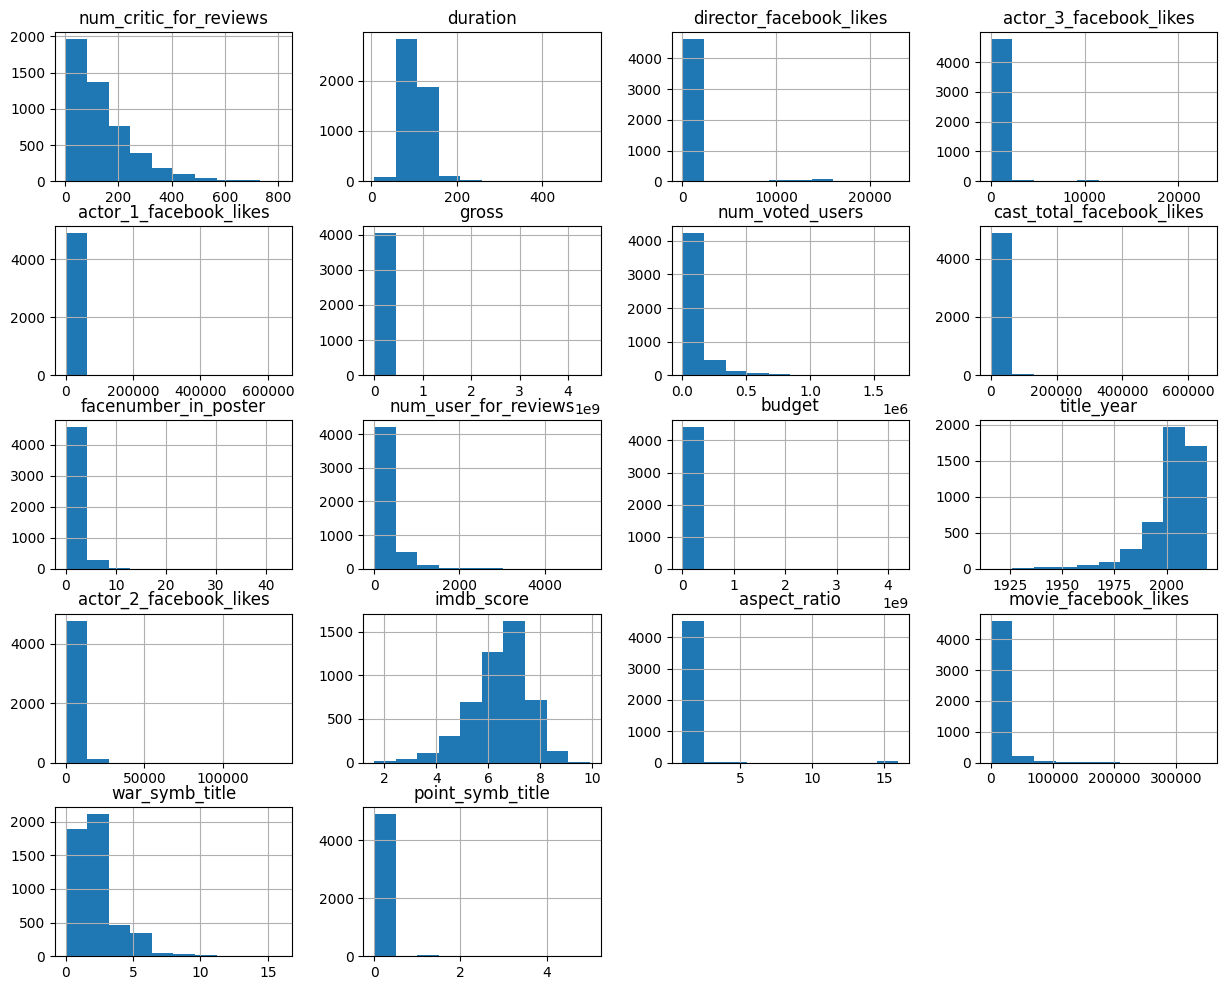

In [16]:
df.hist(figsize=(15,12))
plt.show()

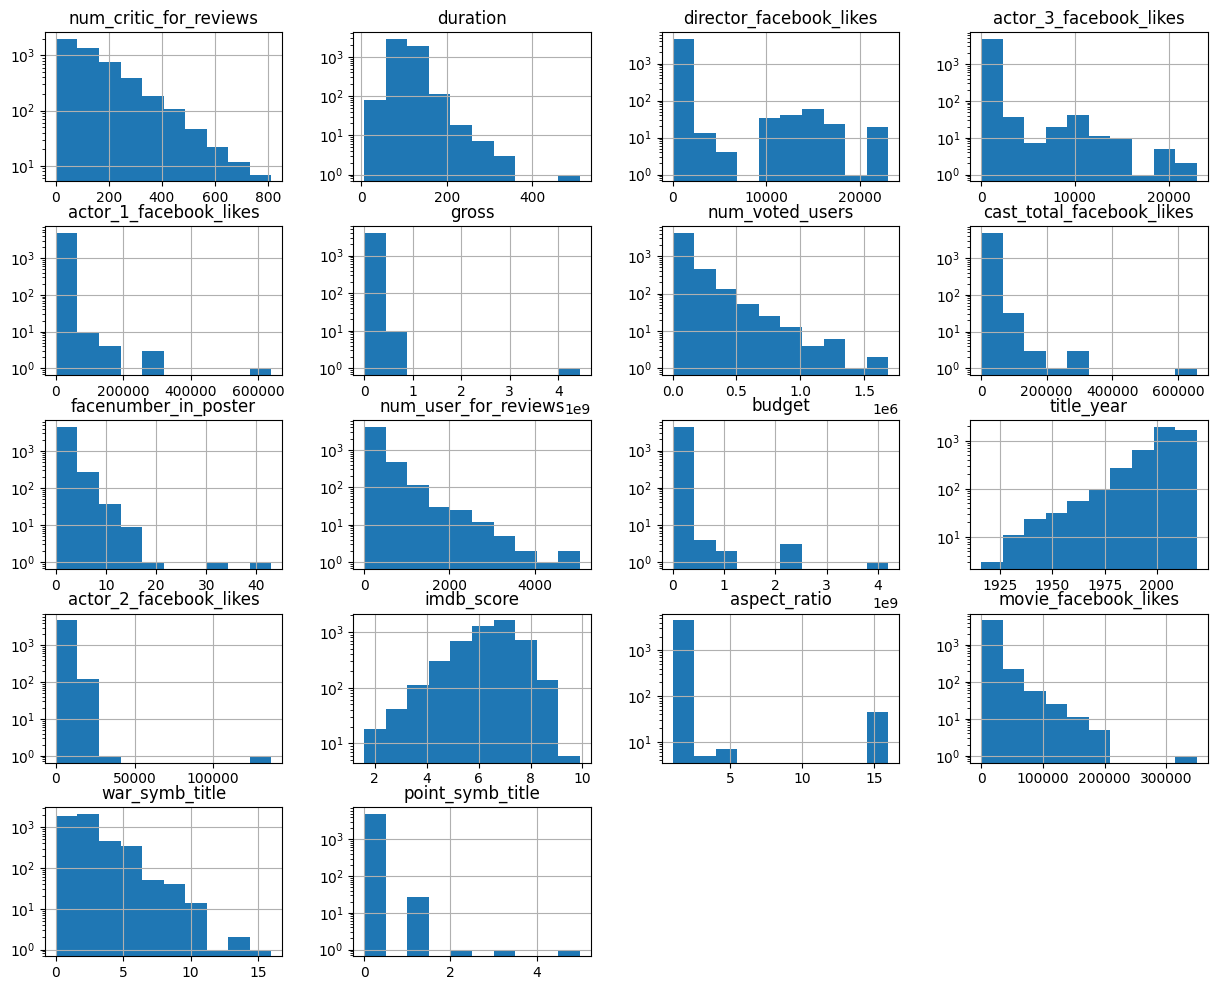

In [17]:
df.hist(figsize=(15,12), log=True)
plt.show()

In [18]:
# key observations:
#   - most of the feauters have right-skewed distribution -> log transformation might be used

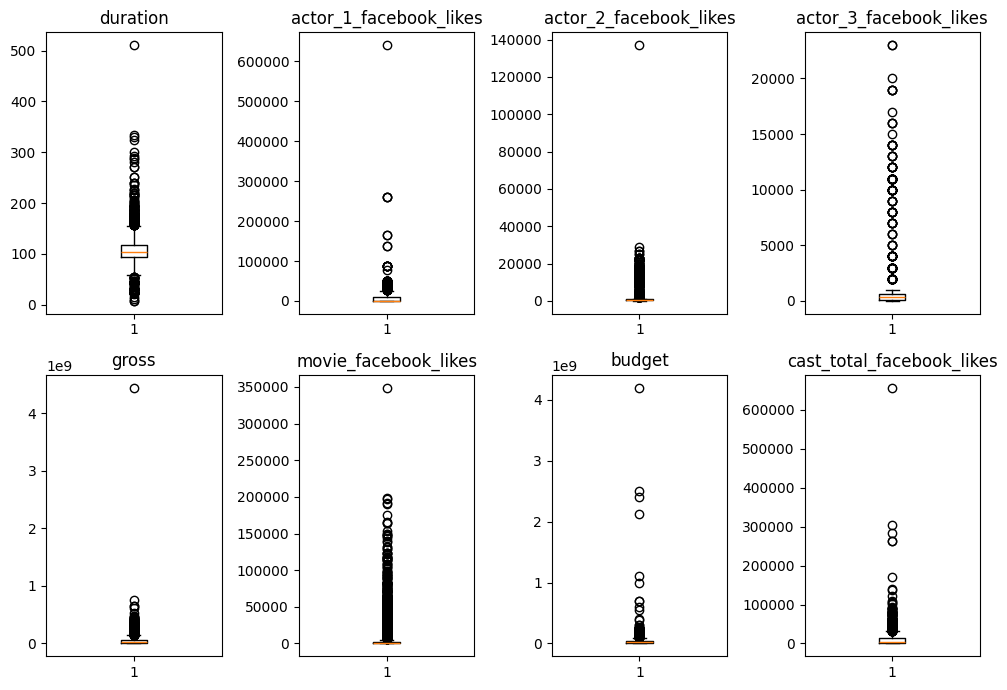

In [19]:
variables_to_check = ["duration", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "gross", "movie_facebook_likes", "budget", "cast_total_facebook_likes"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10,7))
axes = axes.flatten()

for i, col in enumerate(variables_to_check):
    data = (df[col].dropna())
    axes[i].boxplot(data)
    axes[i].set_title(col)

plt.tight_layout()

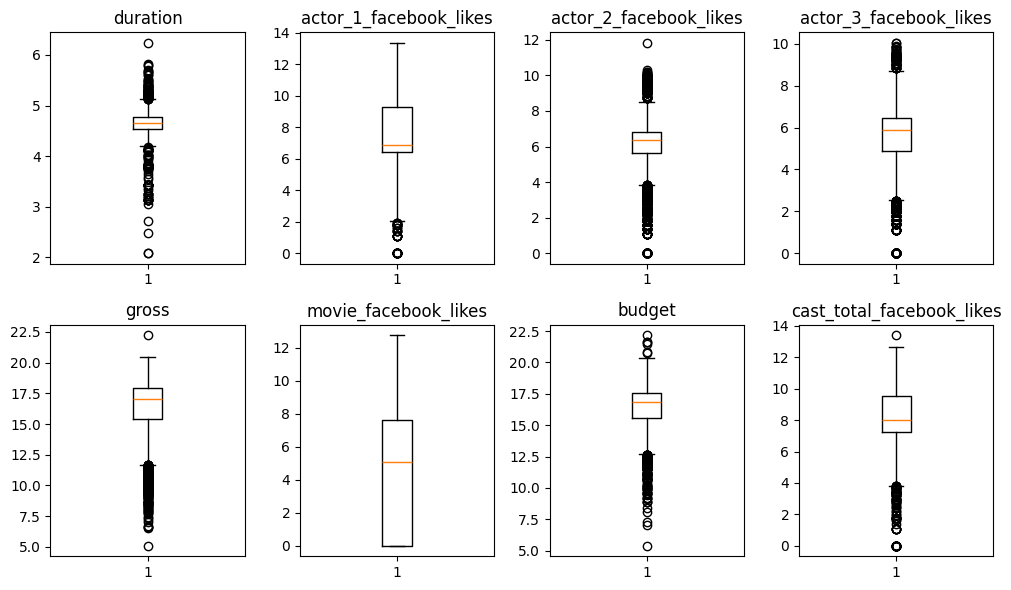

In [20]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate(variables_to_check):
    data = np.log1p(df[col].dropna())
    axes[i].boxplot(data)
    axes[i].set_title(col)

plt.tight_layout()

In [21]:
df[df.duration>300]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1501,Color,Taylor Hackford,12.0000,330.0000,138.0000,672.0000,Jesse Borrego,848.0000,4496583.0000,Crime|Drama,Delroy Lindo,"Blood In, Blood Out",23181,3227,Raymond Cruz,2.0000,1970s|1980s|barrio|gang war|mexican,http://www.imdb.com/title/tt0106469/?ref_=fn_t...,129.0000,English,USA,R,35000000.0000,1993.0000,674.0000,8.0000,1.6600,6000,0,0
2467,Color,NaN,108.0000,334.0000,NaN,30.0000,Nora von Waldstätten,897.0000,145118.0000,Biography|Crime|Drama|Thriller,Edgar Ramírez,Carlos,10111,1032,Katharina Schüttler,0.0000,opec|pubic hair|revolutionary|terrorism|true c...,http://www.imdb.com/title/tt1321865/?ref_=fn_t...,36.0000,English,France,Not Rated,NaN,NaN,30.0000,7.7000,2.3500,0,2,0
1144,Color,Michael Cimino,102.0000,325.0000,517.0000,678.0000,Sam Waterston,12000.0000,1500000.0000,Adventure|Drama|Western,Jeff Bridges,Heaven's Gate,9830,14255,Isabelle Huppert,0.0000,1890s|hired gun|immigrant|johnson county war|s...,http://www.imdb.com/title/tt0080855/?ref_=fn_t...,189.0000,English,USA,R,44000000.0000,1980.0000,849.0000,6.8000,2.3500,1000,2,0
1710,Color,NaN,16.0000,511.0000,NaN,51.0000,Ingvar Eggert Sigurðsson,147.0000,NaN,Crime|Drama|Thriller,Ólafur Darri Ólafsson,Trapped,2308,307,Björn Hlynur Haraldsson,0.0000,coastal town|iceland|police|snowstorm|winter s...,http://www.imdb.com/title/tt3561180/?ref_=fn_t...,19.0000,Icelandic,Iceland,NaN,NaN,NaN,63.0000,8.2000,16.0000,0,2,0


In [22]:
# fake duration
df.loc[df.movie_title == "Blood In, Blood Out\xa0", "duration"] = 180

In [23]:
df[df.actor_1_facebook_likes>250000] # fake number of likes

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1903,Color,Adam McKay,181.0000,98.0000,285.0000,7000.0000,Will Ferrell,640000.0000,84136909.0000,Comedy,Darcy Donavan,Anchorman: The Legend of Ron Burgundy,267921,656730,Steve Carell,5.0000,1970s|anchorman|news anchor|newsroom|tv station,http://www.imdb.com/title/tt0357413/?ref_=fn_t...,577.0000,English,USA,PG-13,26000000.0000,2004.0000,8000.0000,7.2000,1.8500,0,5,0
4593,Color,Johnny Remo,2.0000,112.0000,74.0000,891.0000,Randy Wayne,260000.0000,96734.0000,Action|Drama,Matthew Ziff,Hardflip,606,263584,Raquel Elizabeth Ames,3.0000,family relationships|loss of mother|san diego ...,http://www.imdb.com/title/tt1907639/?ref_=fn_t...,5.0000,English,USA,PG-13,1000000.0000,2012.0000,984.0000,5.6000,1.8500,706,2,0
4410,NaN,John Stockwell,2.0000,90.0000,134.0000,354.0000,T.J. Storm,260000.0000,NaN,Action,Matthew Ziff,Kickboxer: Vengeance,246,261818,Sam Medina,5.0000,NaN,http://www.imdb.com/title/tt3082898/?ref_=fn_t...,1.0000,NaN,USA,NaN,17000000.0000,2016.0000,454.0000,9.1000,NaN,0,2,0
4705,Color,Travis Romero,5.0000,67.0000,4.0000,2000.0000,Lorraine Ziff,260000.0000,NaN,Drama|Thriller,Matthew Ziff,Treachery,344,283939,Michael Biehn,5.0000,panties|white panties,http://www.imdb.com/title/tt2380301/?ref_=fn_t...,5.0000,English,USA,NaN,625000.0000,2013.0000,21000.0000,3.9000,NaN,0,3,0


In [24]:
df.loc[df.actor_1_name == "Matthew Ziff", "actor_1_facebook_likes"] = np.nan

In [25]:
df[df.actor_2_facebook_likes>100000] # fake number of likes

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1223,Color,David R. Ellis,221.0000,82.0000,160.0000,748.0000,Andrew Fiscella,164000.0000,66466372.0000,Horror,Krista Allen,The Final Destination,75345,303717,Shantel VanSanten,0.0000,attempted suicide|car crash|collapsing scaffol...,http://www.imdb.com/title/tt1144884/?ref_=fn_t...,290.0000,English,USA,R,40000000.0000,2009.0000,137000.0000,5.2000,2.3500,0,2,0


In [26]:
df.loc[df.actor_2_name == "Andrew Fiscella", "actor_2_facebook_likes"] = np.nan 

In [27]:
df[df.actor_3_facebook_likes>20000] # real numbers

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
97,Color,Christopher Nolan,642.0000,148.0000,22000.0000,23000.0000,Tom Hardy,29000.0000,292568851.0000,Action|Adventure|Sci-Fi|Thriller,Leonardo DiCaprio,Inception,1468200,81115,Joseph Gordon-Levitt,0.0000,ambiguous ending|corporate espionage|dream|sub...,http://www.imdb.com/title/tt1375666/?ref_=fn_t...,2803.0000,English,USA,PG-13,160000000.0000,2010.0000,27000.0000,8.8000,2.3500,175000,0,0
3,Color,Christopher Nolan,813.0000,164.0000,22000.0000,23000.0000,Christian Bale,27000.0000,448130642.0000,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0.0000,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0000,English,USA,PG-13,250000000.0000,2012.0000,23000.0000,8.5000,2.3500,164000,3,0


In [28]:
df[df.gross>1000000000] # some fake row

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
4941,Green and Yellow,Aina Obama,140.0000,108.0000,777.0000,100.0000,200,300.0000,4444444444.0000,Animation|Documentary,Unit 1,A!O!U!I!E!,35701,1488,Unit 3,3.0000,no fate| detroit| michigan| merefa| absolution...,http://www.imdb.com/title/tt2403815/?ref_=fn_t...,3.0000,Morse,Kyrgyzstan,NaN,21345000.0000,2019.0000,3.0000,9.9000,1.0000,7517,1,5


In [29]:
df = df[df.director_name != "Aina Obama"]

In [30]:
df[df.movie_facebook_likes>300000] # real numbers

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
96,Color,Christopher Nolan,712.0000,169.0000,22000.0000,6000.0000,Anne Hathaway,11000.0000,187991439.0000,Adventure|Drama|Sci-Fi,Matthew McConaughey,Interstellar,928227,31488,Mackenzie Foy,1.0000,black hole|father daughter relationship|saving...,http://www.imdb.com/title/tt0816692/?ref_=fn_t...,2725.0000,English,USA,PG-13,165000000.0000,2014.0000,11000.0000,8.6000,2.3500,349000,3,0


In [31]:
df[df.budget > 1000000000]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
3424,Color,Katsuhiro Ôtomo,150.0000,124.0000,78.0000,4.0000,Takeshi Kusao,6.0000,439162.0000,Action|Animation|Sci-Fi,Mitsuo Iwata,Akira,106160,28,Tesshô Genda,0.0000,based on manga|biker gang|gifted child|post th...,http://www.imdb.com/title/tt0094625/?ref_=fn_t...,430.0000,Japanese,Japan,R,1100000000.0000,1988.0000,5.0000,8.1000,1.8500,0,3,0
3006,Color,Lajos Koltai,73.0000,134.0000,45.0000,0.0000,Péter Fancsikai,9.0000,195888.0000,Drama|Romance|War,Marcell Nagy,Fateless,5603,11,Bálint Péntek,0.0000,bus|death|gay slur|hatred|jewish,http://www.imdb.com/title/tt0367082/?ref_=fn_t...,45.0000,Hungarian,Hungary,R,2500000000.0000,2005.0000,2.0000,7.1000,2.3500,607,1,0
3860,Color,Chan-wook Park,202.0000,112.0000,0.0000,38.0000,Yeong-ae Lee,717.0000,211667.0000,Crime|Drama,Min-sik Choi,Lady Vengeance,53508,907,Hye-jeong Kang,0.0000,cake|christian|lesbian sex|oral sex|pregnant s...,http://www.imdb.com/title/tt0451094/?ref_=fn_t...,131.0000,Korean,South Korea,R,4200000000.0000,2005.0000,126.0000,7.7000,2.3500,4000,2,0
2324,Color,Hayao Miyazaki,174.0000,134.0000,6000.0000,745.0000,Jada Pinkett Smith,893.0000,2298191.0000,Adventure|Animation|Fantasy,Minnie Driver,Princess Mononoke,221552,2710,Billy Crudup,0.0000,anime|cult film|forest|princess|studio ghibli,http://www.imdb.com/title/tt0119698/?ref_=fn_t...,570.0000,Japanese,Japan,PG-13,2400000000.0000,1997.0000,851.0000,8.4000,1.8500,11000,1,0
2335,Color,Katsuhiro Ôtomo,105.0000,103.0000,78.0000,101.0000,Robin Atkin Downes,488.0000,410388.0000,Action|Adventure|Animation|Family|Sci-Fi|Thriller,William Hootkins,Steamboy,13727,991,Rosalind Ayres,1.0000,19th century|ball|boy|inventor|steam,http://www.imdb.com/title/tt0348121/?ref_=fn_t...,79.0000,Japanese,Japan,PG-13,2127519898.0000,2004.0000,336.0000,6.9000,1.8500,973,1,0


In [32]:
df[df.cast_total_facebook_likes > 500000] # real numbers

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
1903,Color,Adam McKay,181.0000,98.0000,285.0000,7000.0000,Will Ferrell,640000.0000,84136909.0000,Comedy,Darcy Donavan,Anchorman: The Legend of Ron Burgundy,267921,656730,Steve Carell,5.0000,1970s|anchorman|news anchor|newsroom|tv station,http://www.imdb.com/title/tt0357413/?ref_=fn_t...,577.0000,English,USA,PG-13,26000000.0000,2004.0000,8000.0000,7.2000,1.8500,0,5,0


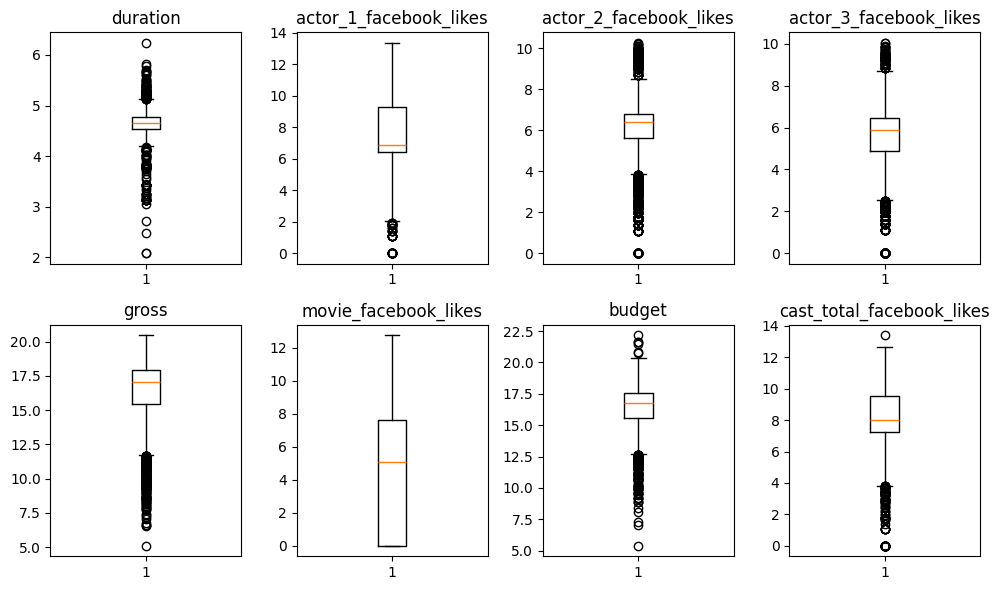

In [33]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10,6))
axes = axes.flatten()

for i, col in enumerate(variables_to_check):
    data = np.log1p((df[col].dropna()))
    axes[i].boxplot(data)
    axes[i].set_title(col)

plt.tight_layout()

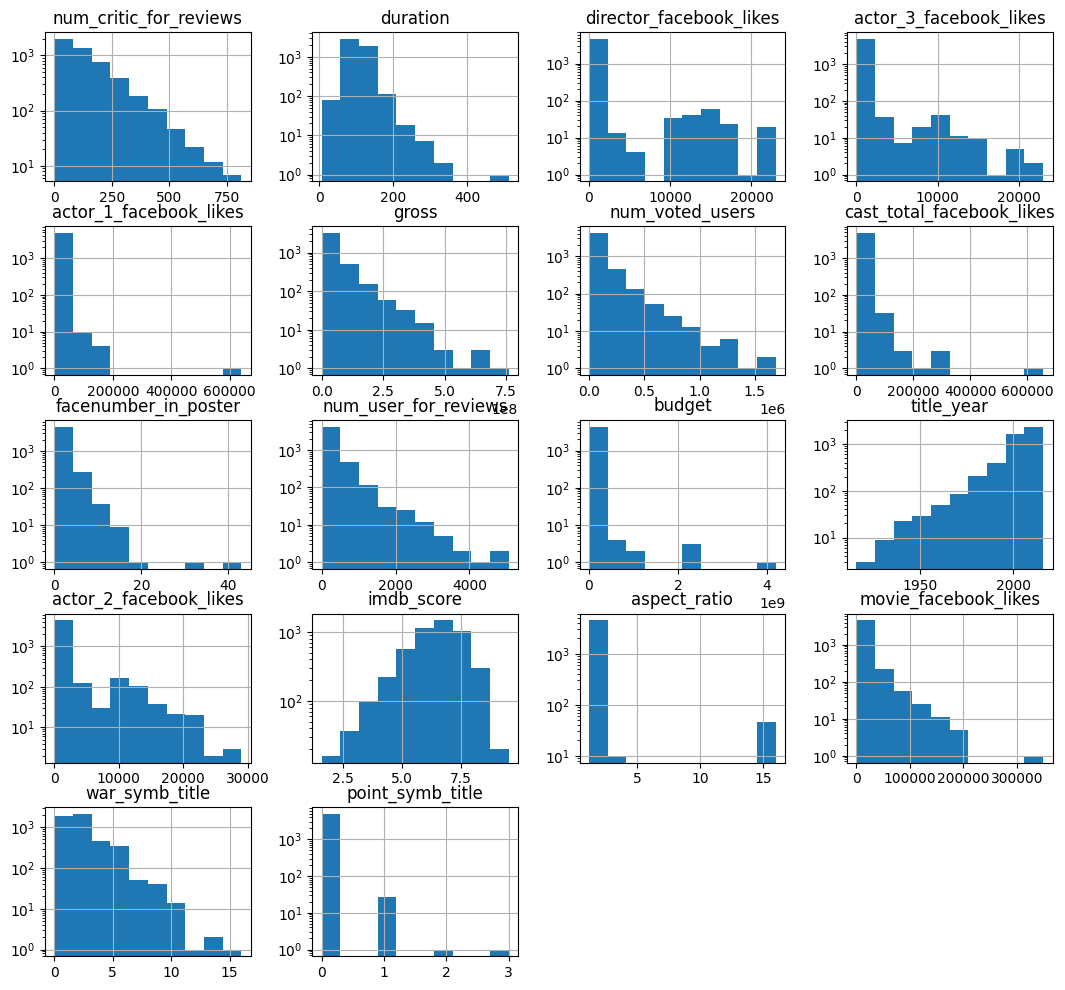

In [34]:
df.hist(figsize=(13,12), log=True)
plt.show()

### 2.3 Correlation

In [35]:
cor = df.select_dtypes(include=[np.number]).corr()

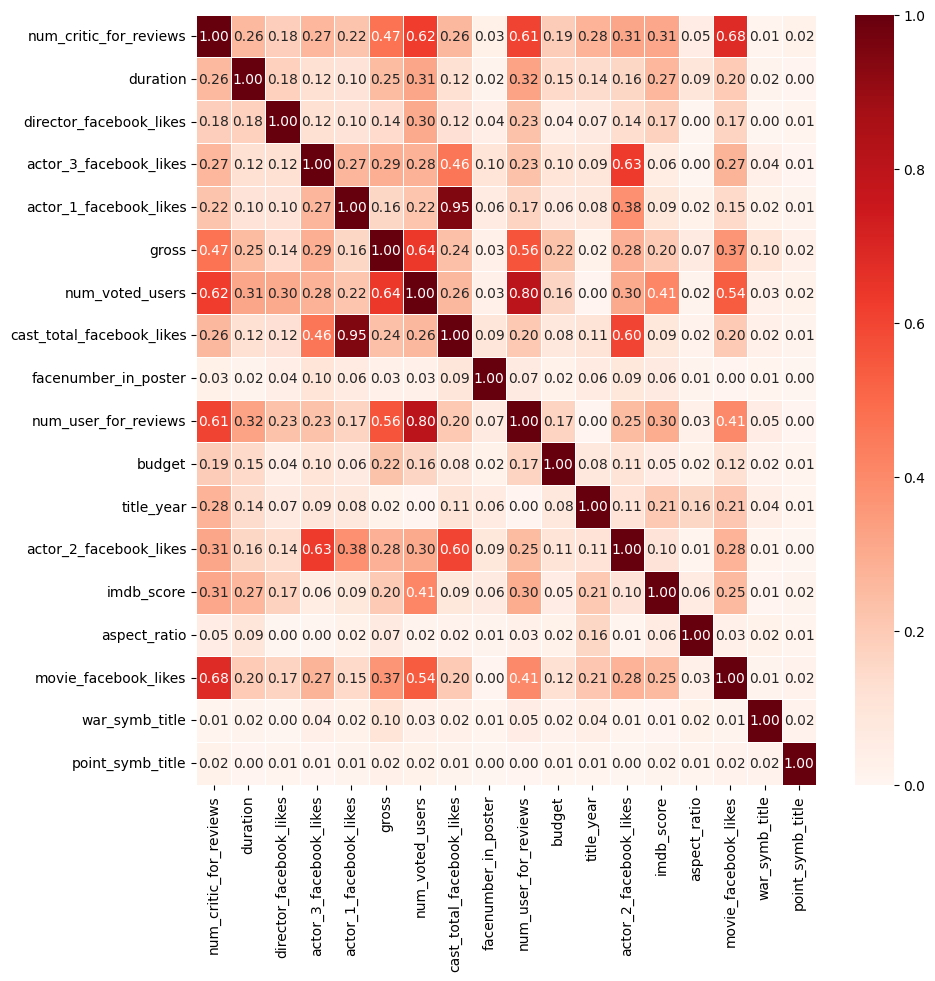

In [36]:
plt.figure(figsize=(10,10))
sns.heatmap(abs(cor), cmap='Reds',annot=True, fmt=".2f",vmin=0, linewidths=0.7)
plt.show()

In [37]:
# cast_total_facebook_light obviously is highly correleted with actor_1/2_facebook_likes, so we should consider removing this feature or do some feature enigneering

In [38]:
df = df.drop("cast_total_facebook_likes", axis = 1)

## 2.4 Feature engineering

In [39]:
(df["num_user_for_reviews"] / df["num_voted_users"])

4448   0.0271
3699   0.0035
3016   0.0318
2846   0.0025
279       NaN
        ...  
4243   0.0028
2152   0.0068
790    0.0041
585    0.0052
882    0.0048
Length: 4916, dtype: float64

In [40]:
df.language.value_counts()

language
English       4582
French          73
Spanish         40
Hindi           28
Mandarin        24
German          19
Japanese        17
Cantonese       11
Italian         11
Russian         11
Portuguese       8
Korean           7
Arabic           5
Swedish          5
Hebrew           5
Danish           5
Persian          4
Dutch            4
Norwegian        4
Chinese          3
Polish           3
Thai             3
Romanian         2
Zulu             2
Icelandic        2
Dari             2
Aboriginal       2
Indonesian       2
Maya             1
Telugu           1
Kannada          1
Greek            1
Hungarian        1
Czech            1
Bosnian          1
Vietnamese       1
Slovenian        1
Urdu             1
Mongolian        1
Kazakh           1
Panjabi          1
Swahili          1
Filipino         1
Aramaic          1
Dzongkha         1
Tamil            1
Name: count, dtype: int64

In [41]:
df.country.value_counts()

country
USA          3711
UK            434
France        154
Canada        122
Germany        94
             ... 
Indonesia       1
Peru            1
Egypt           1
New Line        1
Turkey          1
Name: count, Length: 65, dtype: int64

In [42]:
class PrepareData(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=10):

        self.min_count = min_count

        self.top_ratings = ['R', 'PG-13', 'PG', 'G', 'Unrated']
        self.unrated_names = ['Unrated', 'Not Rated']

        self.top_aspect_ratio = [1.85, 2.35]
    
    def _calculate_means(self, feature_data, y):
        """
        target encoding for pipe-separated categories
        """
        df_tmp = pd.DataFrame({'x': feature_data, 'y': y})
        df_tmp['x'] = df_tmp.x.fillna("Unknown").str.split("|")
        df_tmp = df_tmp.explode('x')

        counts = df_tmp.x.value_counts()
        valid_category = counts[counts >= self.min_count].index

        df_filtered = df_tmp[df_tmp.x.isin(valid_category)]

        means = df_filtered.groupby("x")["y"].mean().to_dict()

        global_mean = np.mean(y)

        return means, global_mean
    
    def _create_new_feature(self, feature_data, means_dict, global_mean):
        """
        maps text categories to target means
        """
        result =  feature_data.fillna("Unknown").str.split("|").explode().map(means_dict).fillna(global_mean).groupby(level=0).mean()
        return result.reindex(feature_data.index).fillna(global_mean)
    
    def fit(self,X,y):
        # non-numerical data
        self.means_genres_, self.global_mean_genres_ = self._calculate_means(X.genres, y)
        self.means_keywords_, self.global_mean_keywords_ = self._calculate_means(X.plot_keywords, y)

        self.actor_counts_ = pd.concat([X.actor_1_name, X.actor_2_name, X.actor_3_name]).dropna().value_counts()
        self.director_counts_ = X.director_name.dropna().value_counts()

        return self 

    def transform(self, X):
        X_copy = X.copy()

        X_copy["genres_mean_target"] = self._create_new_feature(X.genres, self.means_genres_, self.global_mean_genres_)
        X_copy["plot_keywords_mean_target"] = self._create_new_feature(X.plot_keywords, self.means_keywords_, self.global_mean_keywords_)
        
        X_copy["actor_counts"] = X.actor_1_name.map(self.actor_counts_).fillna(0) + X.actor_2_name.map(self.actor_counts_).fillna(0) + X.actor_3_name.map(self.actor_counts_).fillna(0)
        X_copy["director_counts"] = X.director_name.map(self.director_counts_).fillna(0)

        X_copy["is_USA"] = (X_copy.country == "USA").astype(int)
        X_copy["is_english"] = (X_copy.language == "English").astype(int)

        X_copy.content_rating = X_copy.content_rating.replace(self.unrated_names, "Unrated")

        for rating in self.top_ratings:
            X_copy[f"is_rating_{rating}"] = (X_copy.content_rating == rating).astype(int)

        for ratio in self.top_aspect_ratio:
            X_copy[f"is_aspect_ratio_{ratio}"] = (X_copy.aspect_ratio == ratio).astype(int)
        
        X_copy[f"is_color"] = (X_copy.color == "Color").astype(int)

        X_copy["review_ratio"] = (X_copy["num_user_for_reviews"] / X_copy["num_voted_users"])

        X_copy = X_copy.drop(["genres", "plot_keywords", "actor_1_name", "actor_2_name", "actor_3_name", "director_name", "country", "language", "color", "num_user_for_reviews", "num_voted_users", "content_rating", "aspect_ratio"],axis=1)

        return X_copy

## 3. Regression task - predict the gorss value

In [43]:
X = df[~df.gross.isna()].drop("gross",axis =1)
y = np.log(df[~df.gross.isna()].gross)
# 20% test, 20% valid, 60% train
x_temp, x_test, y_temp, y_test = train_test_split(X, y,test_size=0.2, random_state=123)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=0.25, random_state=123)

### 3.1 Baseline

In [44]:
baseline_pipeline = Pipeline([('imputer', SimpleImputer(strategy="most_frequent")),('preprocess', PrepareData()), ('lr_model', LinearRegression())])
baseline_pipeline.fit(x_train.drop(["movie_title", "movie_imdb_link"],axis=1), y_train)
y_pred = baseline_pipeline.predict(x_valid.drop(["movie_title", "movie_imdb_link"],axis=1))

In [45]:
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_valid, y_pred)
    mse = mean_squared_error(y_valid, y_pred)
    mae = mean_absolute_error(y_valid, y_pred)
    sqrt_mse = np.sqrt(mse)
    mae_exp = mean_absolute_error(np.exp(y_true), np.exp(y_pred))

    print(f"R2 = {round(r2,4)}\nMSE = {round(mse,4)}\nMAE = {round(mae,4)}\nsqrt(MSE) = {round(sqrt_mse,4)}\nmae_exp = {round(mae_exp,4)}")
    
    return {'r2': r2, 'mse': mse, 'mae': mae, 'sqrt_mse': sqrt_mse, 'mae_exp': mae_exp}

In [46]:
baseline_performance = evaluate_model(y_valid, y_pred)

R2 = 0.5015
MSE = 2.6162
MAE = 1.2294
sqrt(MSE) = 1.6175
mae_exp = 41805530.5882


In [47]:
rf = RandomForestRegressor()
et = ExtraTreesRegressor()
en = ElasticNet()
svr = SVR()

### 3.2 Hyperparameter tuning

#### 3.2.1 HistGradientBossting

In [48]:
gb = HistGradientBoostingRegressor(random_state=123, early_stopping=True, n_iter_no_change=15, max_iter = 500)
gb_params_space = {
    'model__learning_rate': loguniform(0.001, 0.2),
    'model__max_depth': [None, 7, 10,15, 20,25],
    'model__min_samples_leaf': randint(10,40),
    'model__l2_regularization': loguniform(0.000001, 5),
    'model__max_bins': [255,200,150]
}

In [ ]:
gb_pipeline = Pipeline([("preprocessing", PrepareData()), ("model", gb)])
gb_rs = RandomizedSearchCV(gb_pipeline, param_distributions=gb_params_space, n_iter=500, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=123)
gb_rs.fit(x_train.drop(["movie_title", "movie_imdb_link"], axis=1), y_train)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [ ]:
gb_best = gb_rs.best_estimator_
gb_rs.best_params_

In [ ]:
gb_pred = gb_rs.predict(x_valid.drop(["movie_title", "movie_imdb_link"], axis=1))
gb_performance = evaluate_model(y_valid, gb_pred)

#### 3.2.2 RandomForest

In [ ]:
rf = RandomForestRegressor(random_state=123)
rf_params_space = {
    'model__n_estimators': randint(80,800),
    'model__max_depth': [None, 7, 10, 20, 30, 40],
    'model__min_samples_leaf': randint(1,20),
    'model__min_samples_split': randint(2,20),
    'model__max_features': [1.0, 'sqrt', 'log2'],
    'model__max_samples': [None, 0.5, 0.75, 0.9]
}

In [ ]:
rf_pipeline = Pipeline([("preprocessing", PrepareData()), ("model", rf)])
rf_search = RandomizedSearchCV(rf_pipeline, param_distributions=rf_params_space, n_iter=30, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=123)
rf_search.fit(x_train.drop(["movie_title", "movie_imdb_link"], axis=1), y_train)

In [ ]:
rf_best = rf_search.best_estimator_
rf_search.best_params_

In [ ]:
rf_pred = rf_search.predict(x_valid.drop(["movie_title", "movie_imdb_link"], axis=1))
rf_performance = evaluate_model(y_valid, rf_pred)

#### 3.2.3 ElasticNet

In [ ]:
en = ElasticNet(random_state=123, max_iter = 10000)
en_params_space = {
    'model__alpha': loguniform(0.00001, 50),
    'model__l1_ratio': uniform(0, 1),
    'model__selection': ["random", "cyclic"],
    'imputer__strategy': ["mean", "median", "constant"],
    'imputer__add_indicator': [False, True],
    'scaler__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()]
}

In [ ]:
log_transformer = FunctionTransformer(
    np.log1p, validate=True, feature_names_out="one-to-one")

column_log_transformer = ColumnTransformer(transformers=[('log', log_transformer, ['budget', "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes",
                                           "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster", "war_symb_title"])], remainder="passthrough", verbose_feature_names_out=False)

scaler = ColumnTransformer(transformers=[('scaler', StandardScaler(), ["budget", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster",
                           "war_symb_title", "duration", "title_year", "imdb_score", "point_symb_title", "genres_mean_target", "plot_keywords_mean_target", "actor_counts", "director_counts", "review_ratio"])], remainder="passthrough", verbose_feature_names_out=False)

In [ ]:
en_pipeline = Pipeline([('preprocessing', PrepareData()),('imputer', SimpleImputer(strategy='median')), ('log_trainsormer', column_log_transformer),('scaler', scaler), ('model', en)])
en_search = RandomizedSearchCV(en_pipeline, cv=5, random_state=123, verbose=1, n_jobs=-1, n_iter=5000, param_distributions=en_params_space, scoring='neg_root_mean_squared_error')
en_search.fit(x_train.drop(["movie_title", "movie_imdb_link"], axis=1), y_train)

In [ ]:
en_best = en_search.best_estimator_
en_search.best_params_

In [ ]:
en_pred = en_search.predict(x_valid.drop(["movie_title", "movie_imdb_link"], axis=1))
en_performance = evaluate_model(y_valid, en_pred)

#### 3.2.4 SVR

In [ ]:
svr = SVR(max_iter=100000)
svr_params_space = {
    'model__C': loguniform(0.01, 100),
    'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'model__epsilon': loguniform(0.01, 1),
    'model__kernel': ['sigmoid', 'rbf'],
    'imputer__strategy': ['mean', 'median', 'constant'],
    'imputer__add_indicator': [True, False],
    'scaler__scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()]
}

In [ ]:
svr_pipeline = Pipeline([('preprocessing', PrepareData()),('imputer', SimpleImputer(strategy='median')), ('log_trainsormer', column_log_transformer),('scaler', scaler), ('model', svr)])
svr_search = RandomizedSearchCV(svr_pipeline, cv=5, random_state=123, verbose=1, n_jobs=-1, n_iter=1500, param_distributions=svr_params_space, scoring='neg_root_mean_squared_error')
svr_search.fit(x_train.drop(["movie_title", "movie_imdb_link"], axis=1), y_train)

In [ ]:
svr_best = svr_search.best_estimator_
svr_search.best_params_

In [ ]:
svr_pred = svr_search.predict(x_valid.drop(["movie_title", "movie_imdb_link"], axis=1))
svr_performance = evaluate_model(y_valid, svr_pred)

#### 3.2.5 ExtraTrees

In [ ]:
et = ExtraTreesRegressor(random_state=123)
et_parameter_space = {
    'model__n_estimators': randint(100,1300),
    'model__max_depth': [None, 7, 15, 30, 45, 60],
    'model__max_features': [1.0, 0.9, 0.8, 'sqrt', 'log2'],
    'model__min_samples_split': randint(2,20),
    'model__min_samples_leaf': randint(1,15),
    'model__bootstrap': [True, False]
}

In [ ]:
et_pipeline = Pipeline([("preprocessing", PrepareData()), ("model", et)])
et_search = RandomizedSearchCV(et_pipeline, param_distributions=et_parameter_space, n_iter=200, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1, random_state=123)
et_search.fit(x_train.drop(["movie_title", "movie_imdb_link"], axis=1), y_train)

In [ ]:
et_best = et_search.best_estimator_
et_search.best_params_

In [ ]:
et_pred = et_search.predict(x_valid.drop(["movie_title", "movie_imdb_link"], axis=1))
et_performance = evaluate_model(y_valid, et_pred)

In [ ]:
results = {'baseline': baseline_performance,'histGradientBoosting': gb_performance, 'randomForest': rf_performance, 'elasticNet': en_performance, 'svr': svr_performance, 'ExtraTree': et_performance}
pd.DataFrame(results)

## 4. Classification task - predit if imdb_score > 7.5

In [ ]:
X_c = df[~df.imdb_score.isna()].drop("imdb_score",axis = 1)
y_c = df.loc[~df.imdb_score.isna(), "imdb_score"]
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, shuffle=True)
y_train_c = (y_train_c > 7.5).astype(int)
y_test_c = (y_test_c > 7.5).astype(int)

In [ ]:
log_transformer_c = FunctionTransformer(np.log1p, validate=True, feature_names_out="one-to-one")
column_log_transformer_c = ColumnTransformer(transformers=[('log', log_transformer, ['gross','budget', "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster", "war_symb_title"])], remainder="passthrough", verbose_feature_names_out=False)

scaler_c = ColumnTransformer(transformers=[('scaler', StandardScaler(), ["budget", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "movie_facebook_likes", "director_facebook_likes", "num_critic_for_reviews", "facenumber_in_poster", "war_symb_title", "duration", "title_year", "point_symb_title", "genres_mean_target", "plot_keywords_mean_target", "actor_counts", "director_counts", "review_ratio"])],remainder="passthrough",verbose_feature_names_out=False)

In [ ]:
preprocessing_c = Pipeline(steps = [('imputer', SimpleImputer(strategy='most_frequent')),('log_c', column_log_transformer_c), ('preprocessing', PrepareData(min_count=10)), ('scaler_c', scaler_c)])
x_train_c_transformed = preprocessing_c.fit_transform(x_train_c, y_train_c)
x_test_c_transformed = preprocessing_c.transform(x_test_c)
x_test_c_transformed